In [17]:
# ==============================
# 1. Import Libraries
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [19]:
# ==============================
# 2. Load Dataset
# ==============================

movies = pd.read_csv('/kaggle/input/datasets/rajmehra03/movielens100k/movies.csv')
ratings = pd.read_csv('/kaggle/input/datasets/rajmehra03/movielens100k/ratings.csv')

print("Movies Shape:", movies.shape)
print("Ratings Shape:", ratings.shape)

movies.head()

Movies Shape: (9125, 3)
Ratings Shape: (100004, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Unique Users: 671
Unique Movies: 9066


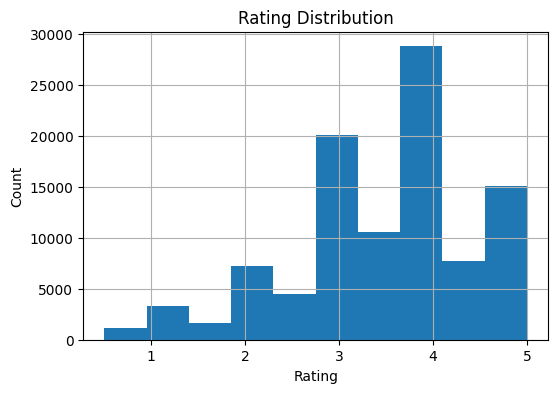

In [20]:
# ==============================
# 3. Exploratory Data Analysis
# ==============================

print("Unique Users:", ratings['userId'].nunique())
print("Unique Movies:", ratings['movieId'].nunique())

plt.figure(figsize=(6,4))
ratings['rating'].hist(bins=10)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [21]:
# ==============================
# 4. Content-Based Filtering
# ==============================

movies['genres'] = movies['genres'].fillna('')

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['genres'])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

In [22]:
def content_recommend(title, top_n=5):
    
    if title not in indices:
        return ["Movie not found"]
    
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    movie_indices = [i[0] for i in sim_scores[1:top_n+1]]
    
    return movies['title'].iloc[movie_indices].tolist()

In [23]:
# ==============================
# 5. Collaborative Filtering
# ==============================

user_movie_matrix = ratings.pivot_table(index='userId', 
                                        columns='movieId', 
                                        values='rating').fillna(0)

user_similarity = cosine_similarity(user_movie_matrix)

user_similarity_df = pd.DataFrame(user_similarity,
                                  index=user_movie_matrix.index,
                                  columns=user_movie_matrix.index)

In [24]:
def collaborative_recommend(user_id, top_n=5):
    
    if user_id not in user_movie_matrix.index:
        return ["User not found"]
    
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:11]
    similar_users_ratings = user_movie_matrix.loc[similar_users.index]
    
    mean_ratings = similar_users_ratings.mean().sort_values(ascending=False)
    
    watched_movies = user_movie_matrix.loc[user_id]
    watched_movies = watched_movies[watched_movies > 0].index
    
    recommendations = mean_ratings.drop(watched_movies, errors='ignore')
    
    recommended_movie_ids = recommendations.head(top_n).index
    
    return movies[movies['movieId'].isin(recommended_movie_ids)]['title'].tolist()

In [25]:
# ==============================
# 6. Weighted Hybrid Model
# ==============================

def weighted_hybrid_recommend(user_id, title, alpha=0.6, beta=0.4, top_n=5):
    
    if title not in indices:
        return ["Movie not found"]
    
    if user_id not in user_movie_matrix.index:
        return ["User not found"]
    
    # Content scores
    idx = indices[title]
    content_scores = list(enumerate(cosine_sim[idx]))
    content_df = pd.DataFrame(content_scores, columns=['index', 'content_score'])
    
    # Collaborative scores
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:11]
    similar_users_ratings = user_movie_matrix.loc[similar_users.index]
    collab_scores = similar_users_ratings.mean().reset_index()
    collab_scores.columns = ['movieId', 'collab_score']
    
    # Merge
    merged = content_df.merge(movies[['movieId']], 
                              left_on='index', 
                              right_index=True)
    
    merged = merged.merge(collab_scores, on='movieId', how='left')
    merged['collab_score'] = merged['collab_score'].fillna(0)
    
    # Weighted score
    merged['final_score'] = alpha * merged['content_score'] + beta * merged['collab_score']
    
    top_movies = merged.sort_values('final_score', ascending=False).head(top_n)
    
    return movies.iloc[top_movies['index']]['title'].tolist()

In [26]:
train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)

In [27]:
global_mean = train_data['rating'].mean()
test_data['predicted_rating'] = global_mean

rmse = np.sqrt(mean_squared_error(test_data['rating'], 
                                  test_data['predicted_rating']))

print("Baseline RMSE:", rmse)

Baseline RMSE: 1.060094011775787


In [28]:
def visualize_content_scores(title):
    
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))[:10]
    
    movie_indices = [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores]
    
    titles = movies['title'].iloc[movie_indices]
    
    plt.figure(figsize=(8,5))
    plt.barh(titles, scores)
    plt.xlabel("Similarity Score")
    plt.title("Top Content-Based Recommendations")
    plt.gca().invert_yaxis()
    plt.show()

In [29]:
print("Content-Based:")
print(content_recommend("Toy Story (1995)", 5))

print("\nCollaborative:")
print(collaborative_recommend(1, 5))

print("\nWeighted Hybrid:")
print(weighted_hybrid_recommend(1, "Toy Story (1995)", top_n=5))

Content-Based:
['Antz (1998)', 'Toy Story 2 (1999)', 'Adventures of Rocky and Bullwinkle, The (2000)', "Emperor's New Groove, The (2000)", 'Monsters, Inc. (2001)']

Collaborative:
['Godfather, The (1972)', "It's a Wonderful Life (1946)", 'Sound of Music, The (1965)', 'Godfather: Part II, The (1974)', 'Beverly Hills Cop (1984)']

Weighted Hybrid:
["It's a Wonderful Life (1946)", 'Antz (1998)', 'Time Bandits (1981)', 'Fantasia (1940)', 'Muppet Movie, The (1979)']
